# 🚗 AI-Based Autonomous Navigation System
## Notebook 1 — System Overview & Architecture

**Author:** Your Name  
**Project:** AI-Autonomous-Navigation-System  
**Purpose:** Introduction to the project architecture, module roles, and the complete pipeline.

---

This notebook gives you a **bird's-eye view** of the entire system before you dive into the code.
It covers:
1. What the project does and why it matters
2. The complete software pipeline
3. How each module connects to the next
4. Quick verification that your environment is set up correctly


## 1. What Is an Autonomous Navigation System?

An Autonomous Navigation System (ANS) is the software brain of a self-driving vehicle. It must:

| Task | What It Means |
|------|---------------|
| **Perceive** | Understand the environment using cameras/sensors |
| **Decide** | Determine the correct behavioral response |
| **Plan** | Compute a safe path to the goal |
| **Control** | Move the vehicle along that path |

**Real-world examples:**
- Waymo One (robotaxi): uses LiDAR + cameras + radar
- Tesla FSD: camera-only neural network stack
- Apollo (Baidu): modular perception → planning → control pipeline

**This project** replicates that architecture in a **2D Pygame simulation** using:
- YOLOv8 for object detection
- OpenCV for lane detection
- A* algorithm for path planning
- A Finite State Machine for decision making
- Ray-cast virtual sensors for proximity detection

## 2. The Complete Pipeline

```
┌─────────────────────────────────────────────────────────────────────┐
│                   Frame-by-Frame Execution Loop                     │
│                                                                     │
│  Step 1: SENSE          Step 2: PERCEIVE       Step 3: DECIDE       │
│  ┌────────────┐         ┌────────────────┐     ┌──────────────┐    │
│  │ VirtualSensor│──────▶│ObstacleDetector│────▶│DecisionMaker │    │
│  │ (5 beams)   │        │(threat assess) │     │(FSM states)  │    │
│  └────────────┘         └────────────────┘     └──────┬───────┘    │
│                                                        │            │
│  Step 4: PLAN                              Step 5: CONTROL          │
│  ┌────────────────────┐                   ┌───────────────────┐    │
│  │  A* PathPlanner    │◀── AVOID state ───│   Car.update()    │    │
│  │  ObstacleAvoidance │──── new path ────▶│  (speed_factor)   │    │
│  └────────────────────┘                   └───────────────────┘    │
│                                                        │            │
│  Step 6: RENDER                                        │            │
│  ┌────────────────────────────────────────────────────▼──────────┐ │
│  │  Environment  +  HUD  +  Sensor Rays  +  Path  +  Car        │ │
│  └──────────────────────────────────────────────────────────────┘ │
└─────────────────────────────────────────────────────────────────────┘
```

## 3. Module Map

| Module | File | Role |
|--------|------|------|
| **YOLODetector** | `src/perception/yolo_detector.py` | Detect objects in image frames |
| **LaneDetector** | `src/perception/lane_detector.py` | Detect lane markings via HoughLines |
| **ObstacleDetector** | `src/perception/obstacle_detector.py` | Proximity threat assessment |
| **VirtualSensor** | `src/simulation/sensor.py` | Ray-cast ultrasonic simulation |
| **DecisionMaker** | `src/navigation/decision_maker.py` | FSM: DRIVE/SLOW/STOP/AVOID/ARRIVE |
| **AStarPlanner** | `src/navigation/planner.py` | 8-directional A* path search |
| **Controller** | `src/navigation/controller.py` | Path smoothing + waypoint tracking |
| **ObstacleAvoidance** | `src/navigation/obstacle_avoidance.py` | Dynamic inflation + replan |
| **Car** | `src/simulation/car.py` | Vehicle kinematic agent |
| **Environment** | `src/simulation/environment.py` | Pygame window + map render |
| **MapLoader** | `src/simulation/map_loader.py` | Procedural city grid |
| **ObstacleManager** | `src/simulation/obstacles.py` | Dynamic obstacle placement |
| **SimLogger** | `src/utils/logger.py` | Structured event logging |
| **HUD** | `src/utils/visualizer.py` | Heads-up display overlay |

In [1]:
# ──────────────────────────────────────────────
# STEP 0: Verify environment setup
# ──────────────────────────────────────────────
import sys, os

# Add project root to path so 'src' is importable
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f'Python: {sys.version}')
print(f'Project root: {project_root}')
print(f'Working dir : {os.getcwd()}')

Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]
Project root: c:\Users\kusan\OneDrive\Desktop\AI based autonomous navigation system
Working dir : c:\Users\kusan\OneDrive\Desktop\AI based autonomous navigation system\notebooks


In [2]:
# ──────────────────────────────────────────────
# STEP 1: Check all required libraries
# ──────────────────────────────────────────────
import importlib

REQUIRED = [
    ('pygame',       'Simulation window'),
    ('cv2',          'OpenCV — lane detection'),
    ('numpy',        'Numerical computing'),
    ('ultralytics',  'YOLOv8 framework'),
    ('matplotlib',   'Plotting & visualization'),
    ('pandas',       'Data analysis'),
]

print('Library Check:')
print('─' * 45)
all_ok = True
for lib, desc in REQUIRED:
    try:
        mod = importlib.import_module(lib)
        ver = getattr(mod, '__version__', 'OK')
        print(f'  ✅ {lib:<15}  {ver:<12}  {desc}')
    except ImportError:
        print(f'  ❌ {lib:<15}  MISSING      {desc}')
        all_ok = False

print('─' * 45)
print('✅ All required libraries present!' if all_ok else '⚠️  Run: pip install -r requirements.txt')

Library Check:
─────────────────────────────────────────────


C:\Users\kusan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.13.12)
Hello from the pygame community. https://www.pygame.org/contribute.html
  ✅ pygame           2.6.1         Simulation window
  ✅ cv2              4.12.0        OpenCV — lane detection
  ✅ numpy            2.2.6         Numerical computing
  ✅ ultralytics      8.4.37        YOLOv8 framework
  ✅ matplotlib       3.10.7        Plotting & visualization
  ✅ pandas           2.3.3         Data analysis
─────────────────────────────────────────────
✅ All required libraries present!


In [3]:
# ──────────────────────────────────────────────
# STEP 2: Import all project modules
# ──────────────────────────────────────────────
from src.config import *
from src.navigation.planner          import astar
from src.navigation.decision_maker   import DecisionMaker
from src.navigation.obstacle_avoidance import ObstacleAvoidance
from src.perception.obstacle_detector import ObstacleDetector

print('✅ All project modules imported successfully')

✅ All project modules imported successfully


In [4]:
# ──────────────────────────────────────────────
# STEP 3: Load and display configuration
# ──────────────────────────────────────────────
import pandas as pd

config_data = {
    'Parameter': [
        'Window Size', 'FPS', 'Car Speed', 'Grid Size',
        'Sensor Range', 'Danger Threshold', 'YOLO Confidence',
        'Start Position', 'Goal Position',
    ],
    'Value': [
        f'{WIDTH} × {HEIGHT} px', str(FPS), f'{CAR_SPEED} px/frame',
        f'{GRID_SIZE} px', f'{SENSOR_RANGE} px', f'{DANGER_THRESHOLD} px',
        f'{YOLO_CONFIDENCE}', str(START_POS), str(GOAL_POS),
    ],
    'Description': [
        'Pygame window resolution', 'Target frame rate',
        'Base vehicle speed', 'A* grid resolution',
        'Sensor max detection range', 'Distance triggering STOP state',
        'YOLO minimum detection confidence', 'Car spawn position',
        'Navigation goal position',
    ]
}

df = pd.DataFrame(config_data)
df.set_index('Parameter', inplace=True)
df

,Value,Description
Parameter,,
Window Size,900 × 650 px,Pygame window resolution
FPS,60,Target frame rate
Car Speed,3.0 px/frame,Base vehicle speed
Grid Size,20 px,A* grid resolution
Sensor Range,100 px,Sensor max detection range
Danger Threshold,40 px,Distance triggering STOP state
YOLO Confidence,0.4,YOLO minimum detection confidence
Start Position,"(60, 60)",Car spawn position
Goal Position,"(820, 570)",Navigation goal position


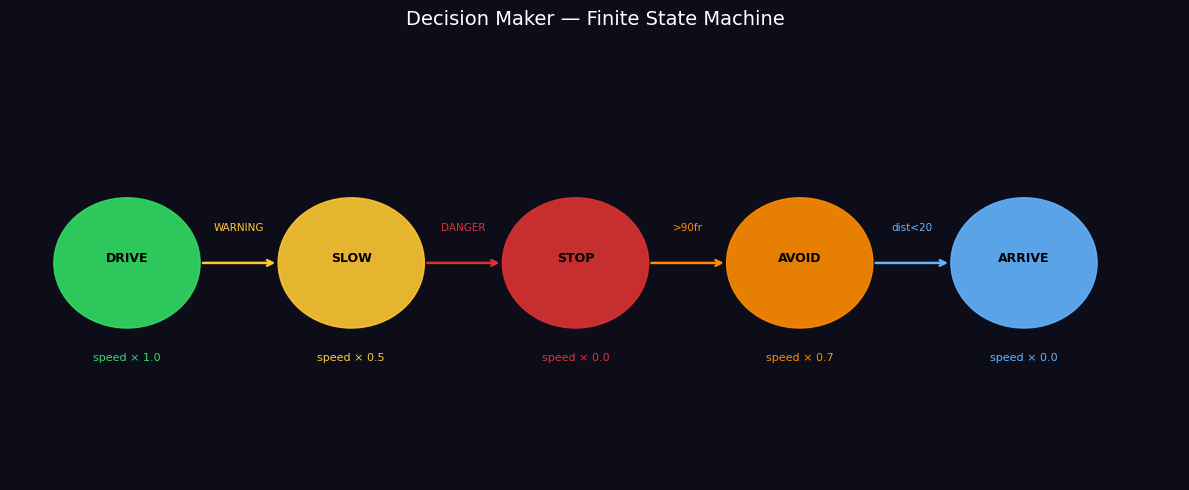

FSM diagram saved to outputs/screenshots/fsm_diagram.png


In [5]:
# ──────────────────────────────────────────────
# STEP 4: Visualize the FSM Decision States
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis('off')
ax.set_facecolor('#0d0d1a')
fig.patch.set_facecolor('#0d0d1a')

states = [
    (1.2, 2.5, 'DRIVE',  '#32dc64', 1.0),
    (3.5, 2.5, 'SLOW',   '#ffc832', 0.5),
    (5.8, 2.5, 'STOP',   '#dc3232', 0.0),
    (8.1, 2.5, 'AVOID',  '#ff8c00', 0.7),
    (10.4,2.5, 'ARRIVE', '#64b4ff', 0.0),
]

for x, y, label, color, spd in states:
    circle = plt.Circle((x, y), 0.75, color=color, alpha=0.9)
    ax.add_patch(circle)
    ax.text(x, y+0.05, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='black')
    ax.text(x, y-1.1, f'speed × {spd}', ha='center', va='center',
            fontsize=8, color=color)

# Arrows
arrows = [
    (1.95, 2.5, 0.8, 0,  'WARNING', '#ffc832'),
    (4.25, 2.5, 0.8, 0,  'DANGER',  '#dc3232'),
    (6.55, 2.5, 0.8, 0,  '>90fr',   '#ff8c00'),
    (8.85, 2.5, 0.8, 0,  'dist<20', '#64b4ff'),
]
for x, y, dx, dy, label, color in arrows:
    ax.annotate('', xy=(x+dx, y+dy), xytext=(x, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    ax.text(x + dx/2, y + 0.35, label, ha='center', va='bottom',
            fontsize=7.5, color=color)

ax.set_title('Decision Maker — Finite State Machine',
             color='white', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../outputs/screenshots/fsm_diagram.png', dpi=120,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('FSM diagram saved to outputs/screenshots/fsm_diagram.png')

In [7]:
# ──────────────────────────────────────────────
# STEP 5: Project folder structure tree
# ──────────────────────────────────────────────
import os

def print_tree(root, prefix='', ignore=None):
    if ignore is None:
        ignore = {'__pycache__', '.git', 'venv', '.ipynb_checkpoints', 'node_modules'}
    entries = sorted(os.scandir(root), key=lambda e: (not e.is_dir(), e.name.lower()))
    entries = [e for e in entries if e.name not in ignore]
    for i, entry in enumerate(entries):
        connector = '└── ' if i == len(entries) - 1 else '├── '
        icon = '📂 ' if entry.is_dir() else '📄 '
        print(prefix + connector + icon + entry.name)
        if entry.is_dir():
            extension = '    ' if i == len(entries) - 1 else '│   '
            print_tree(entry.path, prefix + extension, ignore)

root = os.path.abspath('..')
print(f'📁 {os.path.basename(root)}/')
print_tree(root)

📁 AI based autonomous navigation system/
├── 📂 assets
│   ├── 📂 test_frames
│   │   ├── 📄 bus.jpg
│   │   ├── 📄 dog.jpg
│   │   └── 📄 zidane.jpg
│   └── 📄 map.png
├── 📂 data
│   ├── 📄 README.md
│   ├── 📄 sample_obstacles.json
│   └── 📄 sample_paths.json
├── 📂 docs
│   ├── 📄 architecture.png
│   ├── 📄 setup_guide.md
│   └── 📄 system_design.md
├── 📂 images
│   └── 📄 architecture.png
├── 📂 models
│   └── 📄 model_info.md
├── 📂 notebooks
│   ├── 📄 01_system_overview.ipynb
│   ├── 📄 02_perception_pipeline.ipynb
│   └── 📄 03_path_planning_demo.ipynb
├── 📂 outputs
│   ├── 📂 logs
│   │   ├── 📄 demo_run.log
│   │   ├── 📄 integration_test.log
│   │   ├── 📄 sim_20260412_220300.log
│   │   ├── 📄 sim_20260412_221119.log
│   │   └── 📄 sim_20260412_221207.log
│   ├── 📂 paths
│   │   └── 📄 demo_path.json
│   └── 📂 screenshots
│       └── 📄 fsm_diagram.png
├── 📂 src
│   ├── 📂 navigation
│   │   ├── 📄 __init__.py
│   │   ├── 📄 controller.py
│   │   ├── 📄 decision_maker.py
│   │   ├── 📄 obstacle_avoidance

## 4. Industry Context

| This Project | Industry Equivalent |
|-------------|--------------------|
| YOLOv8 object detection | Waymo's CNN object detector |
| HoughLines lane detection | OpenPilot's classical lane baseline |
| Ray-cast virtual sensor | LiDAR / ultrasonic ring array |
| A* path planner | Apollo DP (Dynamic Programming) Planner |
| FSM decision maker | Apollo Behavioral Planner |
| Obstacle inflation + replan | Apollo EM (Expectation-Maximization) Planner |
| Pygame simulation | CARLA / Gazebo / SUMO simulator |
| SimLogger | ROS2 rosbag + structured logging |

---

### ➡️ Next Notebook
Open **`02_perception_pipeline.ipynb`** to run YOLO object detection and lane detection on real images.